In [62]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
)
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
print('setup complete')

setup complete


# PCA

In [33]:

participant_features = pd.read_csv("../data/interim/participant_features.csv")
participant_features_std = StandardScaler().fit_transform(participant_features.select_dtypes(include='number'))


pca = PCA().fit(participant_features_std)


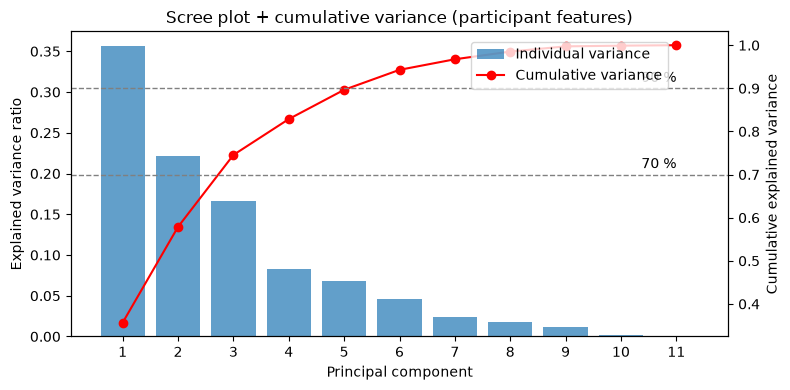

In [34]:

expl_var = pca.explained_variance_ratio_  # eigenvalue shares, sorted (Step 4)
cum_var = expl_var.cumsum()
pcs = range(1, len(expl_var) + 1)

fig, ax1 = plt.subplots(figsize=(8, 4))

# bars = variance per PC
ax1.bar(pcs, expl_var, alpha=0.7, label="Individual variance")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance ratio")
ax1.set_xticks(pcs)

# secondary y-axis for cumulative curve
ax2 = ax1.twinx()
ax2.plot(pcs, cum_var, color="red", marker="o", label="Cumulative variance")
ax2.set_ylabel("Cumulative explained variance")

# horizontal helper lines (e.g. 70 %, 90 %)
for thresh in [0.7, 0.9]:
    ax2.axhline(thresh, ls="--", lw=1, color="grey")
    ax2.text(len(pcs), thresh + 0.015, f"{thresh * 100:.0f} %", ha="right")

# legends & title
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.9))
plt.title("Scree plot + cumulative variance (participant features)")
plt.tight_layout()
plt.show()


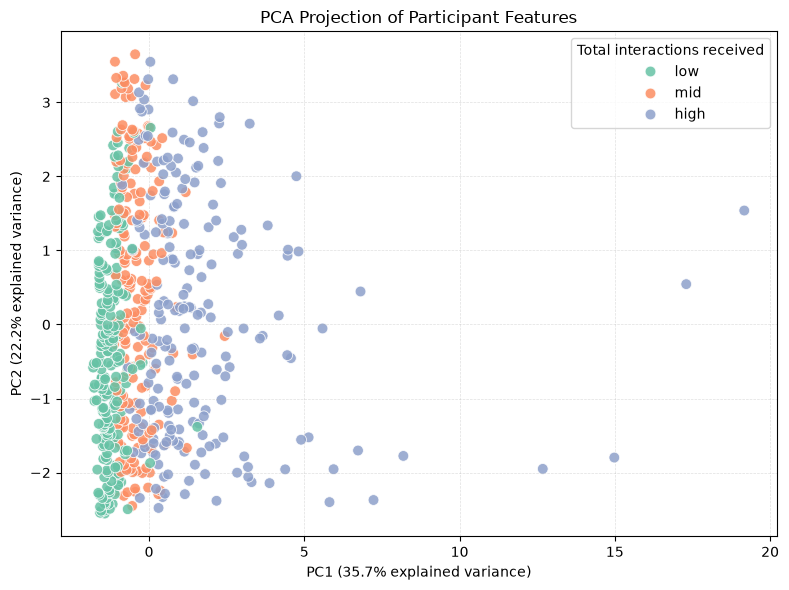

In [35]:
# Project the standardized participant features onto the first two PCs.
pca_embedding = pca.transform(participant_features_std)[:, :2]

# Use the same external color labels as the t-SNE scatterplot.
total_interactions_received = participant_features['total_interactions_received']
colour_label = pd.qcut(
    total_interactions_received, 3, labels=['low', 'mid', 'high']
)

df_pca = pd.DataFrame(pca_embedding, columns=['PC1', 'PC2'])
df_pca['label'] = colour_label.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='label',
    palette='Set2',
    s=60,
    alpha=0.85,
)
plt.title('PCA Projection of Participant Features')
plt.xlabel(f'PC1 ({expl_var[0]:.1%} explained variance)')
plt.ylabel(f'PC2 ({expl_var[1]:.1%} explained variance)')
plt.legend(title='Total interactions received', loc='best', frameon=True)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

# t-SNE

t-SNE does not decompose variance and therefore has no `explained_variance_ratio_`. After the matching scatterplot, neighborhood trustworthiness is plotted as the appropriate dimensionality-reduction quality diagnostic.

In [53]:

seed = 42
# All six steps of the conceptual algorithm run inside TSNE():
#   Steps 1-2 (similarities + symmetrize): pairwise distances -> joint
#       neighbor probabilities p_ij; perplexity=30 sets each point's
#       bandwidth sigma_i (~30 effective neighbors).
#   Step 3 (initialize): init="pca" replaces the random start with a PCA
#       layout -- a more stable, more reproducible initialization.
#   Steps 4-5 (heavy-tailed q_ij + minimize KL): gradient descent in 2-D;
#       learning_rate="auto" picks the step size.
#   Step 6 (iterate): runs for the default 1000 iterations.
#   random_state=seed pins the stochastic parts -- without it, every run
#       gives a different map.
tsne = TSNE(
    n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=seed
).fit_transform(participant_features_std)


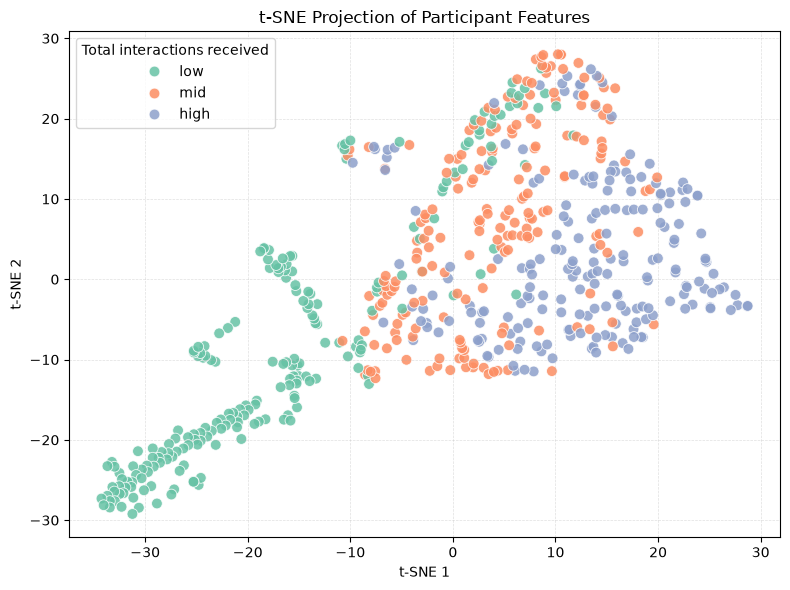

In [54]:
# Use the same color labels and visual styling as the PCA scatterplot.
df_tsne = pd.DataFrame(tsne, columns=["TSNE1", "TSNE2"])
df_tsne["label"] = colour_label.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_tsne,
    x="TSNE1",
    y="TSNE2",
    hue="label",
    palette="Set2",
    s=60,  # marker size
    alpha=0.85,
)

plt.title("t-SNE Projection of Participant Features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Total interactions received", loc="best", frameon=True)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()


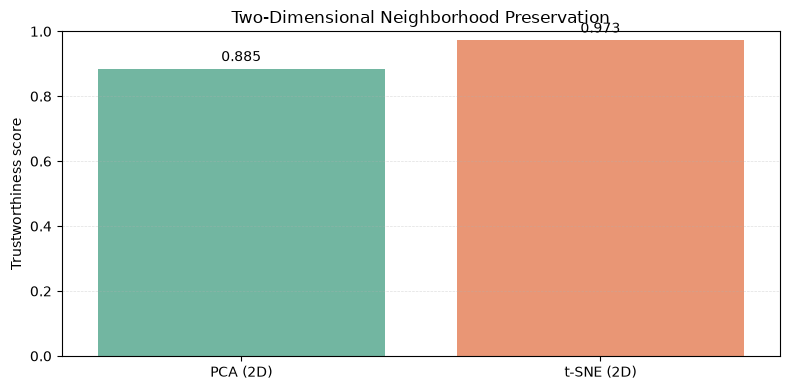

,Method,Trustworthiness
0,PCA (2D),0.885182
1,t-SNE (2D),0.972851


In [55]:
# t-SNE has no explained-variance ratio. Trustworthiness measures how well
# local neighborhoods in the original feature space survive in two dimensions.
quality_scores = pd.DataFrame(
    {
        'Method': ['PCA (2D)', 't-SNE (2D)'],
        'Trustworthiness': [
            trustworthiness(participant_features_std, pca_embedding, n_neighbors=10),
            trustworthiness(participant_features_std, tsne, n_neighbors=10),
        ],
    }
)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=quality_scores,
    x='Method',
    y='Trustworthiness',
    hue='Method',
    palette='Set2',
    legend=False,
)
ax.set_ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.title('Two-Dimensional Neighborhood Preservation')
plt.xlabel('')
plt.ylabel('Trustworthiness score')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

display(quality_scores)

# Pairwise dataset

impute the mean for missing values

In [39]:
pairwise_features = pd.read_csv("../data/interim/pairwise_features.csv")
pairwise_features = pairwise_features.fillna(pairwise_features.mean())

pairwise_features.head()

,user_a,user_b,average_proximity_rssi,proximity_measurements,fraction_rssi_above_threshold,fraction_rssi_below_threshold,texts_shared,calls_shared,average_call_contact_time,max_call_contact_time,text_reciprocity,call_reciprocity,active_days,longest_consecutive_days,weekend_interaction_fraction,weekday_interaction_fraction,mutual_friends
0,0,3,-92.000000,2.0,0.0,1.0,34.911047,5.797101,52.723227,140.041322,0.658877,0.296143,1.0,1.0,0.000000,1.000000,2
1,0,5,-92.750000,4.0,0.0,1.0,34.911047,5.797101,52.723227,140.041322,0.658877,0.296143,1.0,1.0,0.000000,1.000000,1
2,0,10,-96.666667,3.0,0.0,1.0,34.911047,5.797101,52.723227,140.041322,0.658877,0.296143,1.0,1.0,0.000000,1.000000,0
3,0,12,-83.785714,28.0,0.0,1.0,34.911047,5.797101,52.723227,140.041322,0.658877,0.296143,3.0,2.0,0.333333,0.666667,1
4,0,13,-94.833333,6.0,0.0,1.0,34.911047,5.797101,52.723227,140.041322,0.658877,0.296143,2.0,1.0,0.000000,1.000000,3


In [40]:


# Keep the interim table unchanged: select complete rows only for this visualization.
pairwise_numeric = pairwise_features.select_dtypes(include='number').drop(
    columns=['user_a', 'user_b']
)
pairwise_complete = pairwise_numeric.dropna().copy()
pairwise_features_std = StandardScaler().fit_transform(pairwise_complete)

pairwise_pca = PCA().fit(pairwise_features_std)

print(f'Pairwise rows in interim data: {len(pairwise_features):,}')
print(f'Complete rows used for PCA/t-SNE: {len(pairwise_complete):,}')

Pairwise rows in interim data: 82,851
Complete rows used for PCA/t-SNE: 82,851


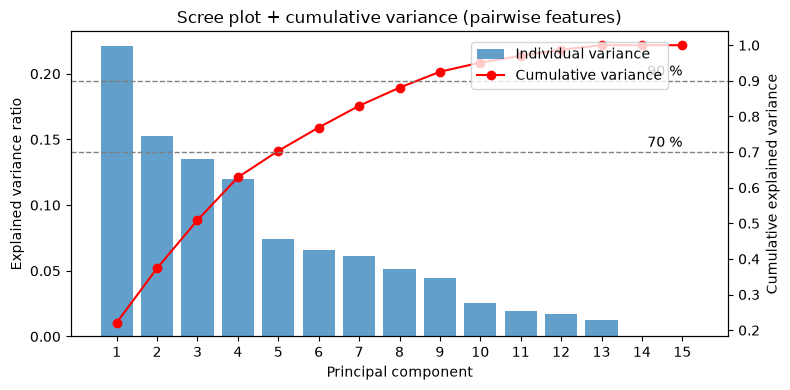

In [41]:
pairwise_expl_var = pairwise_pca.explained_variance_ratio_
pairwise_cum_var = pairwise_expl_var.cumsum()
pairwise_pcs = range(1, len(pairwise_expl_var) + 1)

fig, ax1 = plt.subplots(figsize=(8, 4))

# bars = variance per PC
ax1.bar(pairwise_pcs, pairwise_expl_var, alpha=0.7, label='Individual variance')
ax1.set_xlabel('Principal component')
ax1.set_ylabel('Explained variance ratio')
ax1.set_xticks(pairwise_pcs)

# secondary y-axis for cumulative curve
ax2 = ax1.twinx()
ax2.plot(
    pairwise_pcs,
    pairwise_cum_var,
    color='red',
    marker='o',
    label='Cumulative variance',
)
ax2.set_ylabel('Cumulative explained variance')

# horizontal helper lines (e.g. 70 %, 90 %)
for thresh in [0.7, 0.9]:
    ax2.axhline(thresh, ls='--', lw=1, color='grey')
    ax2.text(len(pairwise_pcs), thresh + 0.015, f'{thresh * 100:.0f} %', ha='right')

fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.9))
plt.title('Scree plot + cumulative variance (pairwise features)')
plt.tight_layout()
plt.show()

## Pairwise t-SNE

In [42]:
pairwise_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=seed,
).fit_transform(pairwise_features_std)

KeyboardInterrupt: 

In [43]:
# Use the same color labels and visual styling as the pairwise PCA scatterplot.
df_pairwise_tsne = pd.DataFrame(pairwise_tsne, columns=['TSNE1', 'TSNE2'])


plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pairwise_tsne,
    x='TSNE1',
    y='TSNE2',
    #hue='label',
    palette='Set2',
    s=60,
    alpha=0.85,
)
plt.title('t-SNE Projection of Pairwise Features')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Total interactions shared', loc='best', frameon=True)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

NameError: name 'pairwise_tsne' is not defined

In [44]:
# As above, use trustworthiness because t-SNE has no explained-variance ratio.
pairwise_quality_scores = pd.DataFrame(
    {
        'Method': ['t-SNE (2D)'],
        'Trustworthiness': [
            
            trustworthiness(
                pairwise_features_std, pairwise_tsne, n_neighbors=10
            ),
        ],
    }
)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=pairwise_quality_scores,
    x='Method',
    y='Trustworthiness',
    hue='Method',
    palette='Set2',
    legend=False,
)
ax.set_ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.title('Pairwise Two-Dimensional Neighborhood Preservation')
plt.xlabel('')
plt.ylabel('Trustworthiness score')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

display(pairwise_quality_scores)

NameError: name 'pairwise_tsne' is not defined

# Index Creation

## Pairwise Facebook-friendship logistic regression

The target is `1` when an unordered pair appears in `interim/fb_friends.csv` and `0` otherwise. The model uses the mean-imputed, standardized `df_pairwise_features_std` created above. Facebook-only pairs with no observed behavioral interaction are excluded to prevent target leakage.

Intentionally leave out strong features to "validate" this index

In [49]:
pairwise_features["pair"] = (
    pairwise_features["user_a"].astype(str)
    + "-"
    + pairwise_features["user_b"].astype(str)
)

temp = StandardScaler().fit_transform(pairwise_numeric)
df_pairwise_features_std = pd.DataFrame(
    temp,
    columns=pairwise_numeric.columns,
    index=pairwise_features.pair,
)
df_pairwise_features_std

,average_proximity_rssi,proximity_measurements,fraction_rssi_above_threshold,fraction_rssi_below_threshold,texts_shared,calls_shared,average_call_contact_time,max_call_contact_time,text_reciprocity,call_reciprocity,active_days,longest_consecutive_days,weekend_interaction_fraction,weekday_interaction_fraction,mutual_friends
pair,,,,,,,,,,,,,,,
0-3,-0.492154,-2.360265e-01,-3.776820e-01,0.377682,-5.317603e-16,2.032179e-15,-1.963289e-15,1.015461e-15,3.764090e-15,0.0,-0.550755,-0.28007,-0.247488,2.474880e-01,0.381455
0-5,-0.622517,-2.194678e-01,-3.776820e-01,0.377682,-5.317603e-16,2.032179e-15,-1.963289e-15,1.015461e-15,3.764090e-15,0.0,-0.550755,-0.28007,-0.247488,2.474880e-01,-0.011243
0-10,-1.303302,-2.277471e-01,-3.776820e-01,0.377682,-5.317603e-16,2.032179e-15,-1.963289e-15,1.015461e-15,3.764090e-15,0.0,-0.550755,-0.28007,-0.247488,2.474880e-01,-0.403941
0-12,0.935632,-2.076240e-02,-3.776820e-01,0.377682,-5.317603e-16,2.032179e-15,-1.963289e-15,1.015461e-15,3.764090e-15,0.0,0.238484,0.70900,1.951577,-1.951577e+00,-0.011243
0-13,-0.984637,-2.029090e-01,-3.776820e-01,0.377682,-5.317603e-16,2.032179e-15,-1.963289e-15,1.015461e-15,3.764090e-15,0.0,-0.156135,-0.28007,-0.247488,2.474880e-01,0.774154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817-831,0.000000,2.941430e-17,-4.701559e-17,0.000000,-5.317603e-16,2.032179e-15,-1.963289e-15,1.015461e-15,3.764090e-15,0.0,0.000000,0.00000,0.000000,1.464871e-15,1.166852
818-823,0.000000,2.941430e-17,-4.701559e-17,0.000000,-5.317603e-16,2.032179e-15,-1.963289e-15,1.015461e-15,3.764090e-15,0.0,0.000000,0.00000,0.000000,1.464871e-15,-0.011243
820-824,0.000000,2.941430e-17,-4.701559e-17,0.000000,-5.317603e-16,2.032179e-15,-1.963289e-15,1.015461e-15,3.764090e-15,0.0,0.000000,0.00000,0.000000,1.464871e-15,7.057326


In [ ]:
fb_friends = pd.read_csv('../data/interim/fb_friends.csv')

# Match the same unordered "smaller-user-larger-user" IDs used by the feature table.
fb_user_a = fb_friends[['user_a', 'user_b']].min(axis=1)
fb_user_b = fb_friends[['user_a', 'user_b']].max(axis=1)
facebook_pair_ids = set(fb_user_a.astype(str) + '-' + fb_user_b.astype(str))

features = [
    "average_proximity_rssi",
    "proximity_measurements",
    "fraction_rssi_above_threshold",
    "fraction_rssi_below_threshold",
    "texts_shared",
    "calls_shared",
    "average_call_contact_time",
    "max_call_contact_time",
    "text_reciprocity",
    "call_reciprocity",
    "active_days",
    "longest_consecutive_days",
    "weekend_interaction_fraction",
    "weekday_interaction_fraction",
    #"mutual_friends",
]

# Restrict candidates to pairs observed in proximity, SMS, or calls.
behavior_candidates = pd.read_csv('../data/interim/pairwise_features.csv')
behavior_candidates['pair'] = (
    behavior_candidates['user_a'].astype(str)
    + '-'
    + behavior_candidates['user_b'].astype(str)
)
behavior_pair_ids = set(
    behavior_candidates.loc[behavior_candidates['active_days'].notna(), 'pair']
)

X = df_pairwise_features_std.loc[
    df_pairwise_features_std.index.isin(behavior_pair_ids), features
].copy()
y = pd.Series(
    X.index.isin(facebook_pair_ids).astype(int),
    index=X.index,
    name='is_facebook_friend',
)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=0,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,
    random_state=0,
    stratify=y_train_val,
)

model = LogisticRegression(penalty='l1', solver='saga', C=1.0, class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f'Modeling rows: {len(X):,}')
print(f'Train/validation/test rows: {len(X_train):,}/{len(X_val):,}/{len(X_test):,}')
print('Target counts:')
display(y.value_counts().rename_axis('is_facebook_friend').rename('count'))

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_prob))

coefficients = pd.concat(
    [
        pd.DataFrame(X.columns, columns=['feature']),
        pd.DataFrame(model.coef_.T, columns=['coefficient']),
    ],
    axis=1,
).sort_values('coefficient', key=abs, ascending=False)
display(coefficients)

/Users/warrensu/Programming/Organizations/cosmos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/warrensu/Programming/Organizations/cosmos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Modeling rows: 82,851
Train/validation/test rows: 57,993/12,430/12,428
Target counts:


/Users/warrensu/Programming/Organizations/cosmos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


is_facebook_friend
0    76433
1     6418
Name: count, dtype: int64

Accuracy: 0.7617476665593821
Recall: 0.39667705088265837
Precision: 0.13830557566980448
F1: 0.2051006711409396
ROC AUC: 0.779498713634299


,feature,coefficient
1,proximity_measurements,0.487070
10,active_days,0.239107
0,average_proximity_rssi,0.197871
11,longest_consecutive_days,0.163848
4,texts_shared,-0.152147
2,fraction_rssi_above_threshold,0.087389
3,fraction_rssi_below_threshold,-0.087389
5,calls_shared,-0.076662
13,weekday_interaction_fraction,-0.064106
12,weekend_interaction_fraction,0.064106


### Bad Performance

# Heuristic Friendship Index and PCA robustness checks

The heuristic score has three pillars: **Investment (35%)**, **Reciprocity (35%)**, and **Intimacy/consistency (30%)**. Volume features use positive-only percentile ranks after `log1p`; zero remains zero. Ratios retain their natural 0–1 scale. Facebook friendship and `mutual_friends` are excluded from index construction and used only for external validation. Facebook-only pairs with no observed behavioral interaction are excluded to prevent target leakage.

In [63]:
# Reload the unmodified interim table rather than using the mean-imputed modeling copy.
friendship_index_data = pd.read_csv('../data/interim/pairwise_features.csv')
# Score only candidate pairs observed in proximity, SMS, or calls.
friendship_index_data = friendship_index_data.loc[
    friendship_index_data['active_days'].notna()
].copy()
friendship_index_data['pair'] = (
    friendship_index_data['user_a'].astype(str)
    + '-'
    + friendship_index_data['user_b'].astype(str)
)
friendship_index_data['is_facebook_friend'] = (
    friendship_index_data['pair'].isin(facebook_pair_ids).astype(int)
)


def positive_percentile(values):
    """Rank positive observations from 0 to 1 while preserving zero as zero."""
    values = values.fillna(0).clip(lower=0)
    transformed = np.log1p(values)
    scores = pd.Series(0.0, index=values.index)
    positive = transformed.gt(0)
    scores.loc[positive] = transformed.loc[positive].rank(pct=True)
    return scores


investment_components = pd.DataFrame(
    {
        'proximity_volume_score': positive_percentile(
            friendship_index_data['proximity_measurements']
        ),
        'text_volume_score': positive_percentile(friendship_index_data['texts_shared']),
        'call_volume_score': positive_percentile(friendship_index_data['calls_shared']),
        'call_time_score': positive_percentile(
            friendship_index_data['average_call_contact_time']
        ),
    }
)

reciprocity_components = pd.DataFrame(
    {
        'text_reciprocity_score': friendship_index_data['text_reciprocity']
        .fillna(0)
        .clip(0, 1),
        'call_reciprocity_score': friendship_index_data['call_reciprocity']
        .fillna(0)
        .clip(0, 1),
    }
)

intimacy_components = pd.DataFrame(
    {
        'weekend_score': friendship_index_data['weekend_interaction_fraction']
        .fillna(0)
        .clip(0, 1),
        'active_days_score': positive_percentile(friendship_index_data['active_days']),
        'consecutive_days_score': positive_percentile(
            friendship_index_data['longest_consecutive_days']
        ),
    }
)

friendship_index_data['investment_pillar'] = investment_components.mean(axis=1)
friendship_index_data['reciprocity_pillar'] = reciprocity_components.mean(axis=1)
friendship_index_data['intimacy_pillar'] = intimacy_components.mean(axis=1)

BASE_WEIGHTS = {
    'investment_pillar': 0.55,
    'reciprocity_pillar': 0.15,
    'intimacy_pillar': 0.30,
}
friendship_index_data['heuristic_index'] = 100 * sum(
    weight * friendship_index_data[pillar]
    for pillar, weight in BASE_WEIGHTS.items()
)

# PCA benchmark uses the same nine normalized behavioral components.
index_components = pd.concat(
    [investment_components, reciprocity_components, intimacy_components], axis=1
)
index_component_std = StandardScaler().fit_transform(index_components)
index_pca = PCA(n_components=1)
pc1_raw = index_pca.fit_transform(index_component_std).ravel()

# PCA signs are arbitrary; orient PC1 in the same broad direction as the heuristic score.
if np.corrcoef(pc1_raw, friendship_index_data['heuristic_index'])[0, 1] < 0:
    pc1_raw *= -1
friendship_index_data['pc1_score'] = (
    pd.Series(pc1_raw, index=friendship_index_data.index).rank(pct=True) * 100
)

display(
    friendship_index_data[
        [
            'user_a', 'user_b', 'investment_pillar', 'reciprocity_pillar',
            'intimacy_pillar', 'heuristic_index', 'pc1_score',
            'is_facebook_friend',
        ]
    ].head()
)

,user_a,user_b,investment_pillar,reciprocity_pillar,intimacy_pillar,heuristic_index,pc1_score,is_facebook_friend
0,0,3,0.079022,0.0,0.222919,11.033773,28.531095,0
1,0,5,0.117055,0.0,0.222919,13.125578,36.591502,0
2,0,10,0.102084,0.0,0.222919,12.302186,33.667746,0
3,0,12,0.201911,0.0,0.667271,31.123250,92.004216,0
4,0,13,0.136615,0.0,0.343487,17.818442,58.397957,0


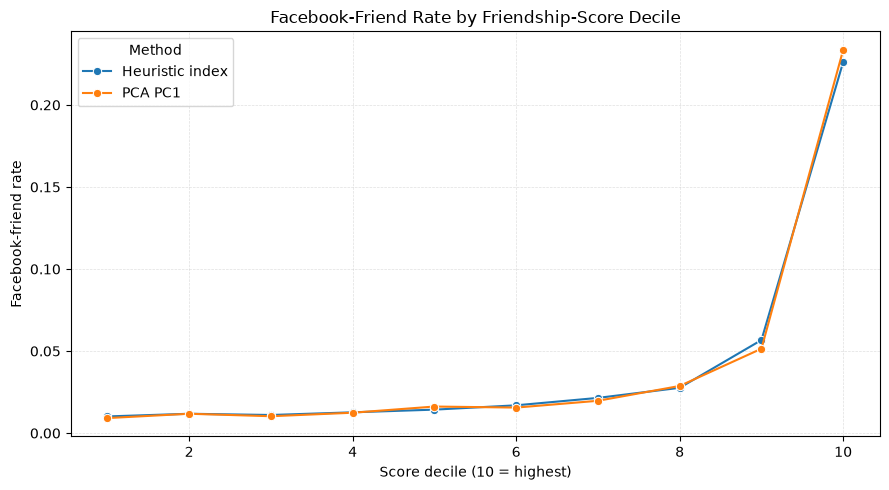

,decile,facebook_friend_rate,pair_count,Method
0,1,0.010163,7970,Heuristic index
1,2,0.011796,7969,Heuristic index
2,3,0.011043,7969,Heuristic index
3,4,0.012674,7969,Heuristic index
4,5,0.014305,7969,Heuristic index
5,6,0.016941,7969,Heuristic index
6,7,0.021458,7969,Heuristic index
7,8,0.027607,7969,Heuristic index
8,9,0.056720,7969,Heuristic index
9,10,0.226223,7970,Heuristic index


In [64]:
# Facebook-friend rate by score decile for both methods.
decile_results = []
for method, score_column in {
    'Heuristic index': 'heuristic_index',
    'PCA PC1': 'pc1_score',
}.items():
    # method='first' breaks exact score ties deterministically by row order.
    deciles = pd.qcut(
        friendship_index_data[score_column].rank(method='first'),
        q=10,
        labels=range(1, 11),
    )
    method_result = (
        friendship_index_data.assign(decile=deciles)
        .groupby('decile', observed=True)['is_facebook_friend']
        .agg(facebook_friend_rate='mean', pair_count='size')
        .reset_index()
    )
    method_result['Method'] = method
    decile_results.append(method_result)

facebook_rate_by_decile = pd.concat(decile_results, ignore_index=True)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=facebook_rate_by_decile,
    x='decile',
    y='facebook_friend_rate',
    hue='Method',
    marker='o',
)
plt.title('Facebook-Friend Rate by Friendship-Score Decile')
plt.xlabel('Score decile (10 = highest)')
plt.ylabel('Facebook-friend rate')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

display(facebook_rate_by_decile)

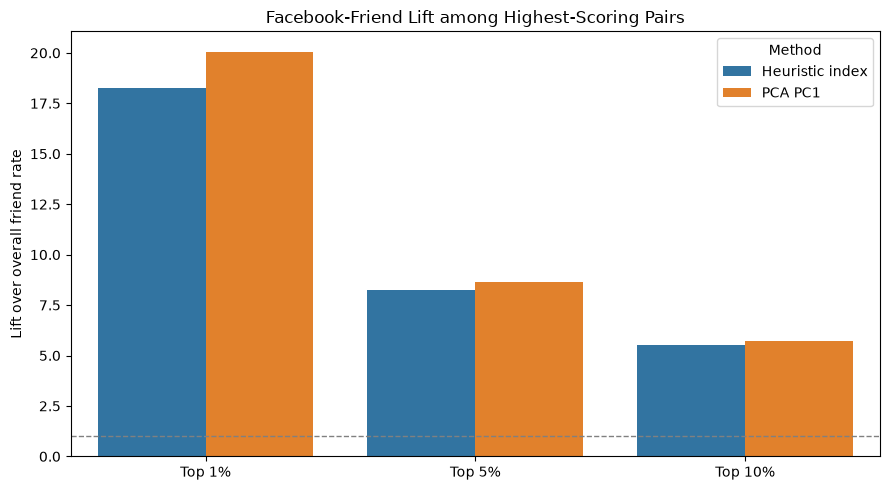

Overall Facebook-friend rate: 4.09%


,Method,Top segment,facebook_friend_rate,lift,pair_count
0,Heuristic index,Top 1%,0.746550,18.255302,797
1,Heuristic index,Top 5%,0.338269,8.271646,3985
2,Heuristic index,Top 10%,0.226223,5.531817,7970
3,PCA PC1,Top 1%,0.820577,20.065491,797
4,PCA PC1,Top 5%,0.353325,8.639820,3985
5,PCA PC1,Top 10%,0.233626,5.712836,7970


In [65]:
# Lift is the top-segment friend rate divided by the overall friend rate.
overall_friend_rate = friendship_index_data['is_facebook_friend'].mean()
lift_rows = []
for method, score_column in {
    'Heuristic index': 'heuristic_index',
    'PCA PC1': 'pc1_score',
}.items():
    for top_fraction in [0.01, 0.05, 0.10]:
        top_count = int(np.ceil(len(friendship_index_data) * top_fraction))
        top_pairs = friendship_index_data.nlargest(top_count, score_column)
        top_friend_rate = top_pairs['is_facebook_friend'].mean()
        lift_rows.append(
            {
                'Method': method,
                'Top segment': f'Top {top_fraction:.0%}',
                'facebook_friend_rate': top_friend_rate,
                'lift': top_friend_rate / overall_friend_rate,
                'pair_count': top_count,
            }
        )

facebook_lift = pd.DataFrame(lift_rows)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=facebook_lift,
    x='Top segment',
    y='lift',
    hue='Method',
    order=['Top 1%', 'Top 5%', 'Top 10%'],
)
ax.axhline(1, color='grey', linestyle='--', linewidth=1)
plt.title('Facebook-Friend Lift among Highest-Scoring Pairs')
plt.xlabel('')
plt.ylabel('Lift over overall friend rate')
plt.tight_layout()
plt.show()

print(f'Overall Facebook-friend rate: {overall_friend_rate:.2%}')
display(facebook_lift)

In [66]:
inspection_columns = [
    'user_a', 'user_b', 'heuristic_index', 'pc1_score',
    'investment_pillar', 'reciprocity_pillar', 'intimacy_pillar',
    'proximity_measurements', 'texts_shared', 'calls_shared',
    'average_call_contact_time', 'text_reciprocity', 'call_reciprocity',
    'active_days', 'longest_consecutive_days', 'weekend_interaction_fraction',
    'is_facebook_friend',
]

heuristic_top_20 = friendship_index_data.nlargest(20, 'heuristic_index')[inspection_columns]
heuristic_bottom_20 = friendship_index_data.nsmallest(20, 'heuristic_index')[inspection_columns]
pca_top_20 = friendship_index_data.nlargest(20, 'pc1_score')[inspection_columns]
pca_bottom_20 = friendship_index_data.nsmallest(20, 'pc1_score')[inspection_columns]

print('Heuristic top 20')
display(heuristic_top_20)
print('Heuristic bottom 20')
display(heuristic_bottom_20)
print('PCA top 20')
display(pca_top_20)
print('PCA bottom 20')
display(pca_bottom_20)

top_20_overlap = len(
    set(heuristic_top_20[['user_a', 'user_b']].itertuples(index=False, name=None))
    & set(pca_top_20[['user_a', 'user_b']].itertuples(index=False, name=None))
)
bottom_20_overlap = len(
    set(heuristic_bottom_20[['user_a', 'user_b']].itertuples(index=False, name=None))
    & set(pca_bottom_20[['user_a', 'user_b']].itertuples(index=False, name=None))
)
print(f'Top-20 overlap: {top_20_overlap}/20')
print(f'Bottom-20 overlap: {bottom_20_overlap}/20')

Heuristic top 20


,user_a,user_b,heuristic_index,pc1_score,investment_pillar,reciprocity_pillar,intimacy_pillar,proximity_measurements,texts_shared,calls_shared,average_call_contact_time,text_reciprocity,call_reciprocity,active_days,longest_consecutive_days,weekend_interaction_fraction,is_facebook_friend
29305,136,137,89.445830,99.998745,0.985675,0.825254,0.761829,3413.0,597.0,29.0,357.107143,0.944625,0.705882,28.0,28.0,0.285714,1
54948,279,617,88.864291,100.000000,0.930834,0.987569,0.761829,2165.0,2860.0,6.0,429.666667,0.975138,1.000000,28.0,28.0,0.285714,1
19797,90,91,88.511277,99.994981,0.970883,0.817188,0.761829,3637.0,779.0,64.0,103.619048,0.904645,0.729730,28.0,28.0,0.285714,1
30057,139,546,88.048857,99.992471,0.941674,0.865278,0.775921,338.0,139.0,9.0,230.888889,0.930556,0.800000,21.0,7.0,0.333333,1
53216,268,521,87.014491,99.991216,0.942594,0.832891,0.755948,1179.0,110.0,23.0,92.608696,0.896552,0.769231,26.0,16.0,0.269231,1
75416,474,639,86.723403,99.997490,0.923184,0.898046,0.749253,324.0,118.0,25.0,66.666667,0.873016,0.923077,24.0,13.0,0.250000,1
45322,218,382,86.552430,99.988707,0.945789,0.778609,0.761829,2945.0,352.0,12.0,121.000000,0.842932,0.714286,28.0,28.0,0.285714,1
68461,390,683,86.144936,99.996236,0.884429,0.988506,0.755791,644.0,172.0,14.0,48.307692,0.977011,1.000000,26.0,13.0,0.269231,1
7723,36,37,85.890363,99.982432,0.969152,0.687500,0.742484,869.0,203.0,39.0,141.571429,0.750000,0.625000,17.0,9.0,0.235294,1
37285,176,578,85.757631,99.977413,0.953950,0.695701,0.761829,1164.0,1764.0,20.0,94.000000,0.852941,0.538462,28.0,28.0,0.285714,1


Heuristic bottom 20


,user_a,user_b,heuristic_index,pc1_score,investment_pillar,reciprocity_pillar,intimacy_pillar,proximity_measurements,texts_shared,calls_shared,average_call_contact_time,text_reciprocity,call_reciprocity,active_days,longest_consecutive_days,weekend_interaction_fraction,is_facebook_friend
2023,9,669,7.328700,52.576168,0.011657,0.0,0.222919,NaN,1.0,NaN,NaN,0.0,NaN,1.0,1.0,0.0,0
33220,155,759,7.328700,52.576168,0.011657,0.0,0.222919,NaN,1.0,NaN,NaN,0.0,NaN,1.0,1.0,0.0,1
37165,176,378,7.328700,52.576168,0.011657,0.0,0.222919,NaN,1.0,NaN,NaN,0.0,NaN,1.0,1.0,0.0,0
47646,233,321,7.328700,52.576168,0.011657,0.0,0.222919,NaN,1.0,NaN,NaN,0.0,NaN,1.0,1.0,0.0,0
52864,266,785,7.328700,52.576168,0.011657,0.0,0.222919,NaN,1.0,NaN,NaN,0.0,NaN,1.0,1.0,0.0,1
53250,268,562,7.328700,52.576168,0.011657,0.0,0.222919,NaN,1.0,NaN,NaN,0.0,NaN,1.0,1.0,0.0,1
70273,408,764,7.328700,52.576168,0.011657,0.0,0.222919,NaN,1.0,NaN,NaN,0.0,NaN,1.0,1.0,0.0,1
75373,474,521,7.328700,52.576168,0.011657,0.0,0.222919,NaN,1.0,NaN,NaN,0.0,NaN,1.0,1.0,0.0,1
76457,489,760,7.328700,52.576168,0.011657,0.0,0.222919,NaN,1.0,NaN,NaN,0.0,NaN,1.0,1.0,0.0,1
78557,528,772,7.328700,52.576168,0.011657,0.0,0.222919,NaN,1.0,NaN,NaN,0.0,NaN,1.0,1.0,0.0,1


PCA top 20


,user_a,user_b,heuristic_index,pc1_score,investment_pillar,reciprocity_pillar,intimacy_pillar,proximity_measurements,texts_shared,calls_shared,average_call_contact_time,text_reciprocity,call_reciprocity,active_days,longest_consecutive_days,weekend_interaction_fraction,is_facebook_friend
54948,279,617,88.864291,100.000000,0.930834,0.987569,0.761829,2165.0,2860.0,6.0,429.666667,0.975138,1.000000,28.0,28.0,0.285714,1
29305,136,137,89.445830,99.998745,0.985675,0.825254,0.761829,3413.0,597.0,29.0,357.107143,0.944625,0.705882,28.0,28.0,0.285714,1
75416,474,639,86.723403,99.997490,0.923184,0.898046,0.749253,324.0,118.0,25.0,66.666667,0.873016,0.923077,24.0,13.0,0.250000,1
68461,390,683,86.144936,99.996236,0.884429,0.988506,0.755791,644.0,172.0,14.0,48.307692,0.977011,1.000000,26.0,13.0,0.269231,1
19797,90,91,88.511277,99.994981,0.970883,0.817188,0.761829,3637.0,779.0,64.0,103.619048,0.904645,0.729730,28.0,28.0,0.285714,1
8502,39,622,84.841074,99.993726,0.913237,0.842217,0.732660,26.0,132.0,48.0,120.818182,0.970149,0.714286,25.0,13.0,0.200000,1
30057,139,546,88.048857,99.992471,0.941674,0.865278,0.775921,338.0,139.0,9.0,230.888889,0.930556,0.800000,21.0,7.0,0.333333,1
53216,268,521,87.014491,99.991216,0.942594,0.832891,0.755948,1179.0,110.0,23.0,92.608696,0.896552,0.769231,26.0,16.0,0.269231,1
71114,420,495,79.401132,99.989961,0.831988,0.824615,0.709086,9.0,23.0,47.0,238.000000,0.769231,0.880000,11.0,3.0,0.181818,0
45322,218,382,86.552430,99.988707,0.945789,0.778609,0.761829,2945.0,352.0,12.0,121.000000,0.842932,0.714286,28.0,28.0,0.285714,1


PCA bottom 20


,user_a,user_b,heuristic_index,pc1_score,investment_pillar,reciprocity_pillar,intimacy_pillar,proximity_measurements,texts_shared,calls_shared,average_call_contact_time,text_reciprocity,call_reciprocity,active_days,longest_consecutive_days,weekend_interaction_fraction,is_facebook_friend
82675,682,699,8.466692,0.010039,0.032348,0.0,0.222919,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0
82686,683,704,8.466692,0.010039,0.032348,0.0,0.222919,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0
82688,683,812,8.466692,0.010039,0.032348,0.0,0.222919,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0
82694,684,698,8.466692,0.010039,0.032348,0.0,0.222919,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0
82696,684,702,8.466692,0.010039,0.032348,0.0,0.222919,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0
82704,685,698,8.466692,0.010039,0.032348,0.0,0.222919,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0
82708,685,812,8.466692,0.010039,0.032348,0.0,0.222919,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0
82714,686,704,8.466692,0.010039,0.032348,0.0,0.222919,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0
82719,687,700,8.466692,0.010039,0.032348,0.0,0.222919,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0
82729,688,704,8.466692,0.010039,0.032348,0.0,0.222919,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0


Top-20 overlap: 14/20
Bottom-20 overlap: 0/20


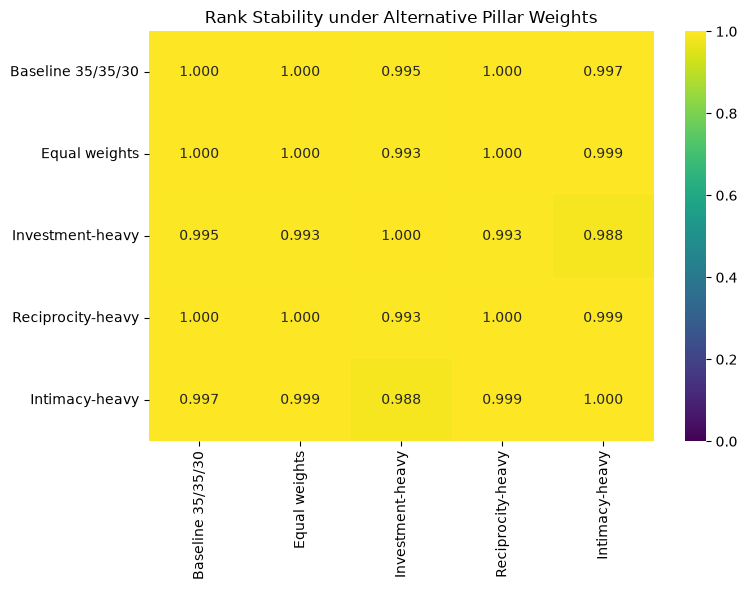

,Baseline 35/35/30,Equal weights,Investment-heavy,Reciprocity-heavy,Intimacy-heavy
Baseline 35/35/30,1.000000,0.999642,0.995262,0.999624,0.997455
Equal weights,0.999642,1.000000,0.993076,0.999968,0.998620
Investment-heavy,0.995262,0.993076,1.000000,0.993017,0.987724
Reciprocity-heavy,0.999624,0.999968,0.993017,1.000000,0.998526
Intimacy-heavy,0.997455,0.998620,0.987724,0.998526,1.000000


In [67]:
# Test whether pair rankings survive plausible alternative pillar weights.
weight_scenarios = {
    'Baseline 35/35/30': (0.35, 0.35, 0.30),
    'Equal weights': (1 / 3, 1 / 3, 1 / 3),
    'Investment-heavy': (0.50, 0.25, 0.25),
    'Reciprocity-heavy': (0.25, 0.50, 0.25),
    'Intimacy-heavy': (0.25, 0.25, 0.50),
}

scenario_scores = pd.DataFrame(index=friendship_index_data.index)
for scenario, (investment_weight, reciprocity_weight, intimacy_weight) in (
    weight_scenarios.items()
):
    scenario_scores[scenario] = 100 * (
        investment_weight * friendship_index_data['investment_pillar']
        + reciprocity_weight * friendship_index_data['reciprocity_pillar']
        + intimacy_weight * friendship_index_data['intimacy_pillar']
    )

rank_stability = scenario_scores.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(rank_stability, annot=True, fmt='.3f', cmap='viridis', vmin=0, vmax=1)
plt.title('Rank Stability under Alternative Pillar Weights')
plt.tight_layout()
plt.show()

display(rank_stability)

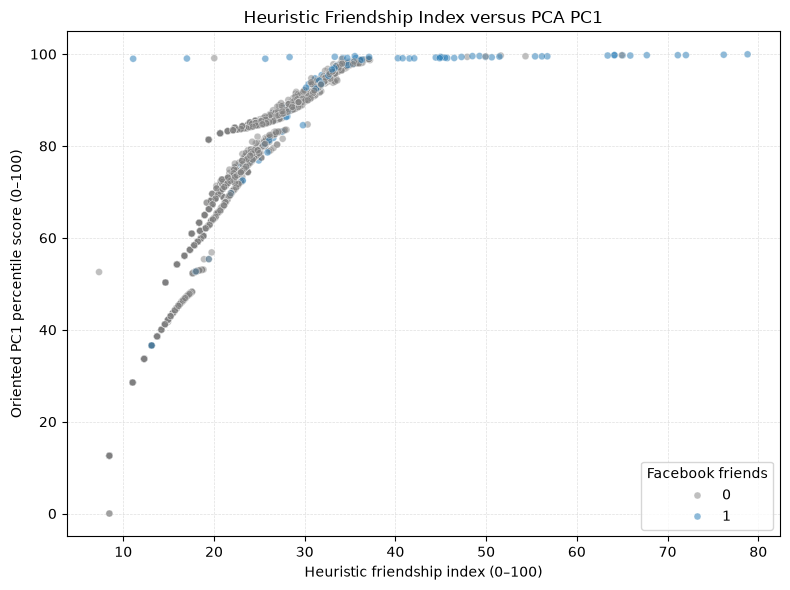

Pearson correlation with PC1: 0.929
Spearman rank correlation with PC1: 0.994


In [68]:
pearson_pc1 = friendship_index_data['heuristic_index'].corr(
    friendship_index_data['pc1_score'], method='pearson'
)
spearman_pc1 = friendship_index_data['heuristic_index'].corr(
    friendship_index_data['pc1_score'], method='spearman'
)

plot_sample = friendship_index_data.sample(
    n=min(5_000, len(friendship_index_data)), random_state=42
)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_sample,
    x='heuristic_index',
    y='pc1_score',
    hue='is_facebook_friend',
    palette={0: 'grey', 1: 'tab:blue'},
    s=25,
    alpha=0.5,
)
plt.title('Heuristic Friendship Index versus PCA PC1')
plt.xlabel('Heuristic friendship index (0–100)')
plt.ylabel('Oriented PC1 percentile score (0–100)')
plt.legend(title='Facebook friends')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Pearson correlation with PC1: {pearson_pc1:.3f}')
print(f'Spearman rank correlation with PC1: {spearman_pc1:.3f}')